In [1]:
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
import seaborn as sns

nominal_power = 2000    # kW

current_dir = Path.cwd()

## Load data
We tried to merge every dataset into one to have more normal behavior data (so our model can perform better) but the duplicated timestamps had also different features values. So instead of just picking one random value, we are going to stick to just one dataset. In this case, we took the `26.csv` due to lar

In [2]:
# df_scada_raw = pd.concat(
#     pd.read_csv(f, sep=";", parse_dates=["time_stamp"])
#     for f in current_dir.glob("datasets/*.csv")
# )             # <--- imports all csv files
df_scada_raw = pd.read_csv(current_dir / "datasets" / "26.csv", sep=";", parse_dates=["time_stamp"])
df_scada_raw = df_scada_raw.drop(columns=["asset_id", "id"])

df_event = pd.read_csv(current_dir / "event_info.csv", sep=";", parse_dates=["event_start", "event_end"])

df_feature_description = pd.read_csv(current_dir / "feature_description.csv", sep=";")


In [3]:
# mapping: sensor_name -> description
desc_map = (
    df_feature_description
    .set_index("sensor_name")["description"]
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .to_dict()
)

def rename_col(col):
    m = re.match(r"(sensor_\d+|power_\d+|reactive_power_\d+|wind_speed_\d+)(?:_(avg|max|min|std))?$", col)

    if not m:
        return col.lower().replace(" ", "_")

    base, suffix = m.groups()
    new = desc_map.get(base, base)

    return f"{new}_{suffix}" if suffix else new

df_scada = df_scada_raw.rename(columns=rename_col)

In [4]:
# # check for duplicates
# df_scada_raw[df_scada_raw.duplicated(subset=["time_stamp"], keep=False)]
# mask = df_scada_raw.drop(columns="train_test")["time_stamp"].duplicated()
# df_scada_raw.drop(columns="train_test")[mask]
# df_scada.drop(columns="train_test").drop_duplicates(subset="time_stamp", keep="first").set_index("time_stamp")

In [5]:
df_normal_operation = df_scada[df_scada.status_type_id.isin([0])]

avg_cols = [col for col in df_normal_operation.columns if col.endswith("_avg")]
df_avg = df_normal_operation[avg_cols]
df_avg

,ambient_temperature_avg,wind_absolute_direction_avg,wind_relative_direction_avg,windspeed_avg,estimated_windspeed_avg,pitch_angle_avg,temperature_in_the_hub_controller_avg,temperature_in_the_top_nacelle_controller_avg,temperature_in_the_choke_coils_on_the_vcs-section_avg,temperature_on_the_vcp-board_avg,...,temperature_measured_by_the_igbt-driver_on_the_rotor_side_inverter_phase2_avg,temperature_measured_by_the_igbt-driver_on_the_rotor_side_inverter_phase3_avg,temperature_in_hv_transformer_phase_l1_avg,temperature_in_hv_transformer_phase_l2_avg,temperature_in_hv_transformer_phase_l3_avg,temperature_oil_in_hydraulic_group_avg,nacelle_direction_avg,nacelle_temperature_avg,rotor_rpm_avg,temperature_in_the_nose_cone_avg
0,17.0,184.0,-10.8,13.2,13.4,7.6,29.0,45.0,120.0,45.0,...,49.0,50.0,81.0,94.0,112.0,50.0,194.9,32.0,14.9,19.0
1,17.0,188.3,-6.2,13.6,14.0,9.0,29.0,45.0,120.0,45.0,...,49.0,50.0,82.0,95.0,113.0,51.0,194.5,33.0,14.9,19.0
2,17.0,186.0,-8.4,12.7,13.2,7.0,29.0,46.0,121.0,45.0,...,49.0,50.0,82.0,95.0,114.0,51.0,194.5,33.0,14.9,19.0
3,18.0,190.8,-3.7,13.4,13.8,8.5,29.0,46.0,121.0,45.0,...,49.0,50.0,83.0,96.0,116.0,45.0,194.5,35.0,14.9,19.0
4,17.0,205.0,10.5,12.7,12.9,6.2,29.0,46.0,121.0,45.0,...,49.0,50.0,83.0,96.0,115.0,43.0,194.5,35.0,14.9,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51249,22.0,93.4,2.7,14.1,13.8,8.7,31.0,45.0,118.0,46.0,...,49.0,50.0,86.0,99.0,98.0,50.0,90.8,37.0,14.9,23.0
51250,23.0,90.0,-0.7,12.9,12.7,5.7,31.0,45.0,118.0,46.0,...,49.0,50.0,87.0,100.0,99.0,50.0,90.8,36.0,14.9,24.0
51251,23.0,88.8,-1.9,12.6,12.3,4.5,31.0,46.0,119.0,46.0,...,48.0,50.0,87.0,100.0,100.0,44.0,90.8,37.0,14.9,24.0
51252,23.0,88.9,-1.8,13.2,12.9,6.6,31.0,46.0,120.0,47.0,...,49.0,50.0,88.0,101.0,100.0,43.0,90.8,37.0,14.9,24.0


In [6]:
# sns.pairplot(df_avg.sample(1000))
# plt.show()

In [7]:
df_scada_raw.head(3)

,time_stamp,train_test,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,wind_speed_3_max,wind_speed_3_min,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,2022-10-12 10:20:00,train,0,17.0,184.0,-10.8,13.2,13.4,31.6,2.3,...,0.0,-36842.0,0.0,333190.0,-36842.0,14.9,15.7,14.0,0.2,19.0
1,2022-10-12 10:30:00,train,0,17.0,188.3,-6.2,13.6,14.0,25.6,3.3,...,0.0,-36493.0,0.0,333266.0,-36493.0,14.9,15.4,14.1,0.2,19.0
2,2022-10-12 10:40:00,train,0,17.0,186.0,-8.4,12.7,13.2,28.6,2.0,...,0.0,-36213.0,0.0,332999.0,-36213.0,14.9,15.6,14.3,0.2,19.0


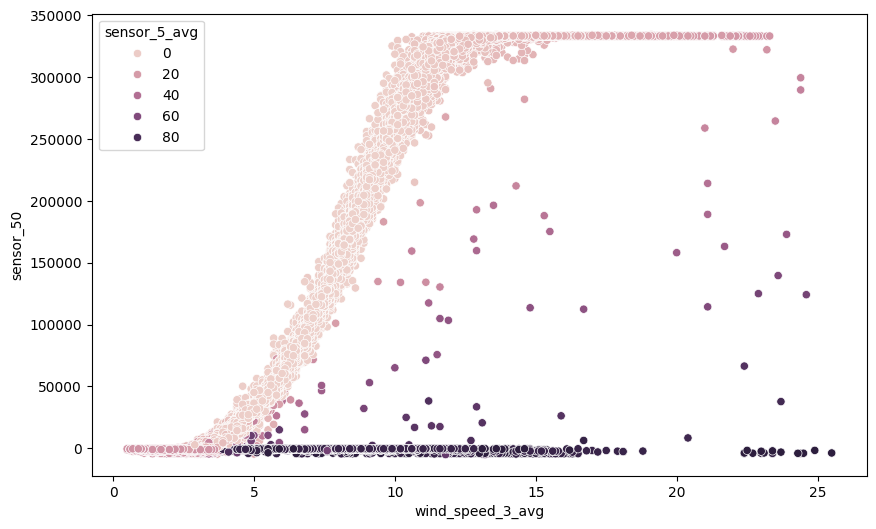

In [8]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(df_scada_raw, x="wind_speed_3_avg", y="sensor_50", hue="sensor_5_avg")
plt.show()

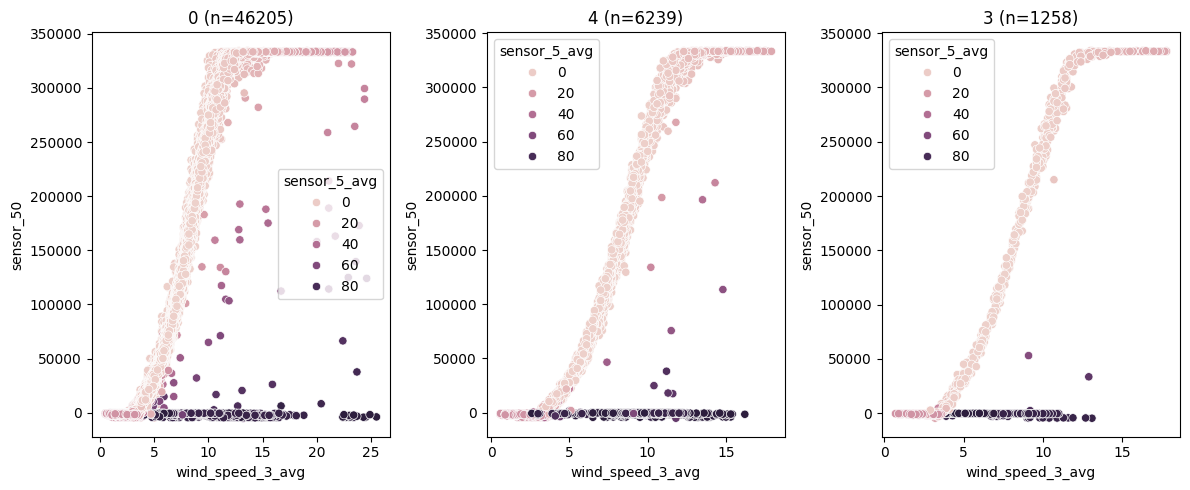

In [9]:
fig, axes = plt.subplots(1, df_scada_raw["status_type_id"].nunique(), figsize=(12, 5))
for idx, status in enumerate(df_scada_raw["status_type_id"].unique()):
    df_subset = df_scada_raw[df_scada_raw["status_type_id"] == status]
    sns.scatterplot(df_subset, x="wind_speed_3_avg", y="sensor_50", ax=axes[idx], hue="sensor_5_avg")
    axes[idx].set_title(f"{status} (n={len(df_subset)})")
plt.tight_layout()
plt.show()

In [10]:
df_feature_description

,sensor_name,statistics_type,description,unit,is_angle,is_counter
0,sensor_0,average,Ambient temperature,�C,False,False
1,sensor_1,average,Wind absolute direction,�,True,False
2,sensor_2,average,Wind relative direction,�,True,False
3,wind_speed_3,"maximum,minimum,average,std_dev",Windspeed,m/s,False,False
4,wind_speed_4,average,Estimated windspeed,m/s,False,False
5,sensor_5,"maximum,minimum,std_dev,average",Pitch angle,�,True,False
6,sensor_6,average,Temperature in the hub controller,�C,False,False
7,sensor_7,average,Temperature in the top nacelle controller,�C,False,False
8,sensor_8,average,Temperature in the choke coils on the VCS-section,�C,False,False
9,sensor_9,average,Temperature on the VCP-board,�C,False,False


## Failure mode selection
For a first approach, we are going to narrow the problem down to one failure and thus, to one failure mode.

>Failure mode in a wind turbine refers to the specific ways in which a component or system can fail, potentially leading to a loss of functionality or performance.

So we select one failure timestamp like the following and select a subset of features that can affect the targeted component. In this case, we are focusing on generator bearing failure and thus, we will select a subset of related damage indicators:

`anomaly,2023-08-06 06:10:00,52436,2023-08-20 06:10:00,54447,Generator bearing failure`

Possible damage indicators (only averages for now):
* 1. **sensor_13_avg** — Temperature in generator bearing 2 (Drive End)
* 2. **sensor_14_avg** — Temperature in generator bearing 1 (Non-Drive End)
* 3. **sensor_15_avg** — Temperature inside generator in stator windings phase 1
* 4. **sensor_16_avg** — Temperature inside generator in stator windings phase 2
* 5. **sensor_17_avg** — Temperature inside generator in stator windings phase 3
* 6. **sensor_18_avg** — Generator rpm in latest period
* 7. **sensor_19_avg** — Temperature in the split ring chamber
* 8. **sensor_20_avg** — Temperature in the busbar section
* 9. **sensor_23_avg** — Averaged current in phase 1
* 10. **sensor_24_avg** — Averaged current in phase 2
* 11. **sensor_25_avg** — Averaged current in phase 3
* 12. **sensor_32_avg** — Averaged voltage in phase 1
* 13. **sensor_33_avg** — Averaged voltage in phase 2
* 14. **sensor_34_avg** — Averaged voltage in phase 3


In [26]:
damage_indicators = [
    "sensor_13_avg",
    "sensor_14_avg",
    "sensor_15_avg",
    "sensor_16_avg",
    "sensor_17_avg",
    "sensor_18_avg",
    "sensor_19_avg",
    "sensor_20_avg",
    "sensor_23_avg",
    "sensor_24_avg",
    "sensor_25_avg",
    "sensor_32_avg",
    "sensor_33_avg",
    "sensor_34_avg",
]
predictors_features = [
    "wind_speed_3_avg",
    "wind_speed_3_std",
    # "sensor_1_avg",
    "sensor_0_avg",
    "sensor_2_avg",
    "sensor_5_avg",
    "sensor_43_avg",
    "sensor_50",
    "sensor_52_avg",
    # "sensor_52_std",
]
df_scada = df_scada_raw.set_index("time_stamp")[["status_type_id", "train_test"] + damage_indicators + predictors_features]

In [12]:
df_scada_raw

,time_stamp,status_type_id,sensor_0_avg,sensor_1_avg,sensor_2_avg,wind_speed_3_avg,wind_speed_4_avg,wind_speed_3_max,wind_speed_3_min,wind_speed_3_std,...,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,sensor_52_avg,sensor_52_max,sensor_52_min,sensor_52_std,sensor_53_avg
0,2022-10-12 10:20:00,0,17.0,184.0,-10.8,13.2,13.4,31.6,2.3,3.0,...,0.0,-36842.0,0.0,333190.0,-36842.0,14.9,15.7,14.0,0.2,19.0
1,2022-10-12 10:30:00,0,17.0,188.3,-6.2,13.6,14.0,25.6,3.3,3.1,...,0.0,-36493.0,0.0,333266.0,-36493.0,14.9,15.4,14.1,0.2,19.0
2,2022-10-12 10:40:00,0,17.0,186.0,-8.4,12.7,13.2,28.6,2.0,3.1,...,0.0,-36213.0,0.0,332999.0,-36213.0,14.9,15.6,14.3,0.2,19.0
3,2022-10-12 10:50:00,0,18.0,190.8,-3.7,13.4,13.8,27.6,1.8,3.3,...,0.0,-36397.0,0.0,333473.0,-36397.0,14.9,15.7,14.2,0.2,19.0
4,2022-10-12 11:00:00,0,17.0,205.0,10.5,12.7,12.9,26.7,1.6,2.8,...,0.0,-35976.0,0.0,332011.0,-35976.0,14.9,15.5,14.5,0.2,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53697,2023-10-22 09:40:00,3,21.0,117.8,65.6,1.4,1.4,3.8,0.4,0.4,...,-6.0,0.0,0.0,-485.0,-6.0,0.0,0.0,0.0,0.0,25.0
53698,2023-10-22 09:50:00,3,20.0,88.5,36.3,1.6,1.6,4.1,0.4,0.4,...,-257.0,0.0,0.0,-772.0,-257.0,0.5,1.7,0.0,0.8,25.0
53699,2023-10-22 10:00:00,3,20.0,40.0,-12.2,2.0,2.0,4.2,0.5,0.4,...,-535.0,0.0,0.0,-1065.0,-535.0,1.4,1.7,0.0,0.6,25.0
53700,2023-10-22 10:10:00,3,19.0,34.8,-17.3,1.7,1.7,4.1,0.5,0.4,...,-527.0,0.0,0.0,-1048.0,-527.0,0.1,1.5,0.0,0.3,24.0


### Missing data

We only have 2 timestamps out of around 53000 data points, so it is meaningless and we can safely discard those rows.

In [13]:
df_scada = df_scada[df_scada.notna()].reset_index()
df_scada = df_scada.rename(columns={"time_stamp":"timestamp"}).copy()
df_scada_raw.isna().sum()

time_stamp        0
status_type_id    0
sensor_0_avg      0
sensor_1_avg      0
sensor_2_avg      0
                 ..
sensor_52_avg     0
sensor_52_max     0
sensor_52_min     0
sensor_52_std     0
sensor_53_avg     0
Length: 83, dtype: int64

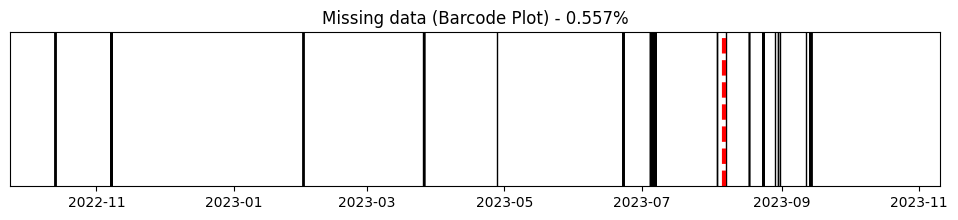

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_scada.copy()
# your dataframe
# df["timestamp"] should be datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

# create full expected time range
full_range = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="10min"   # change to your expected frequency
)

# find missing timestamps
missing = full_range.difference(df["timestamp"])
present = df["timestamp"]

fig, ax = plt.subplots(figsize=(12,2))

# white lines (present timestamps)
ax.vlines(present, 0, 1, color="white", linewidth=1)

# black lines (missing timestamps)
ax.vlines(missing, 0, 1, color="black", linewidth=1)

ax.set_facecolor("white")
ax.set_ylim(0,1)
ax.set_yticks([])
ax.set_title(f"Missing data (Barcode Plot) - {round(len(missing) * 100/len(present), 3)}%")
ax.axvline(pd.Timestamp("2023-08-06 06:10:00"), c="r", linestyle="--", linewidth=3)

plt.show()

### Outliers analysis

In [15]:
df_scada.describe()

,timestamp,status_type_id,sensor_13_avg,sensor_14_avg,sensor_15_avg,sensor_16_avg,sensor_17_avg,sensor_18_avg,sensor_19_avg,sensor_20_avg,...,sensor_33_avg,sensor_34_avg,wind_speed_3_avg,wind_speed_3_std,sensor_0_avg,sensor_2_avg,sensor_5_avg,sensor_43_avg,sensor_50,sensor_52_avg
count,53702,53702.000000,53702.000000,53701.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,...,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000,53702.000000
mean,2023-04-17 15:14:11.085621,0.534989,45.848497,45.314538,68.673029,68.313359,67.125750,1080.945700,30.957078,37.008789,...,397.995250,397.381665,6.374550,1.269267,19.907769,0.707071,9.784045,30.173699,97598.353544,9.508538
min,2022-10-12 10:20:00,0.000000,19.000000,18.000000,21.000000,21.000000,20.000000,0.000000,12.000000,20.000000,...,378.500000,377.700000,0.500000,0.000000,4.000000,-179.800000,-2.300000,15.000000,-5126.000000,0.000000
25%,2023-01-13 22:22:30,0.000000,34.000000,34.000000,44.000000,44.000000,44.000000,286.025000,25.000000,32.000000,...,396.800000,395.900000,3.400000,0.700000,16.000000,-8.600000,-1.700000,26.000000,-471.000000,2.500000
50%,2023-04-17 06:35:00,0.000000,43.000000,43.000000,63.000000,63.000000,63.000000,1285.600000,30.000000,37.000000,...,398.000000,397.300000,5.600000,1.100000,20.000000,0.400000,-0.100000,30.000000,40640.000000,11.400000
75%,2023-07-20 15:47:30,0.000000,56.000000,54.000000,85.000000,85.000000,83.000000,1616.900000,37.000000,42.000000,...,399.200000,398.700000,8.700000,1.700000,24.000000,8.700000,24.000000,34.000000,174164.250000,14.300000
max,2023-10-22 10:20:00,4.000000,205.000000,95.000000,145.000000,143.000000,139.000000,1683.800000,60.000000,62.000000,...,413.800000,414.700000,25.500000,70.000000,39.000000,179.900000,90.000000,50.000000,334355.000000,14.900000
std,NaN,1.335478,15.010144,14.781405,30.626260,30.134905,28.883088,614.086652,8.575345,7.686844,...,1.734041,2.069871,3.786189,0.929770,5.603817,32.859181,19.256835,5.680493,117819.132841,5.548031


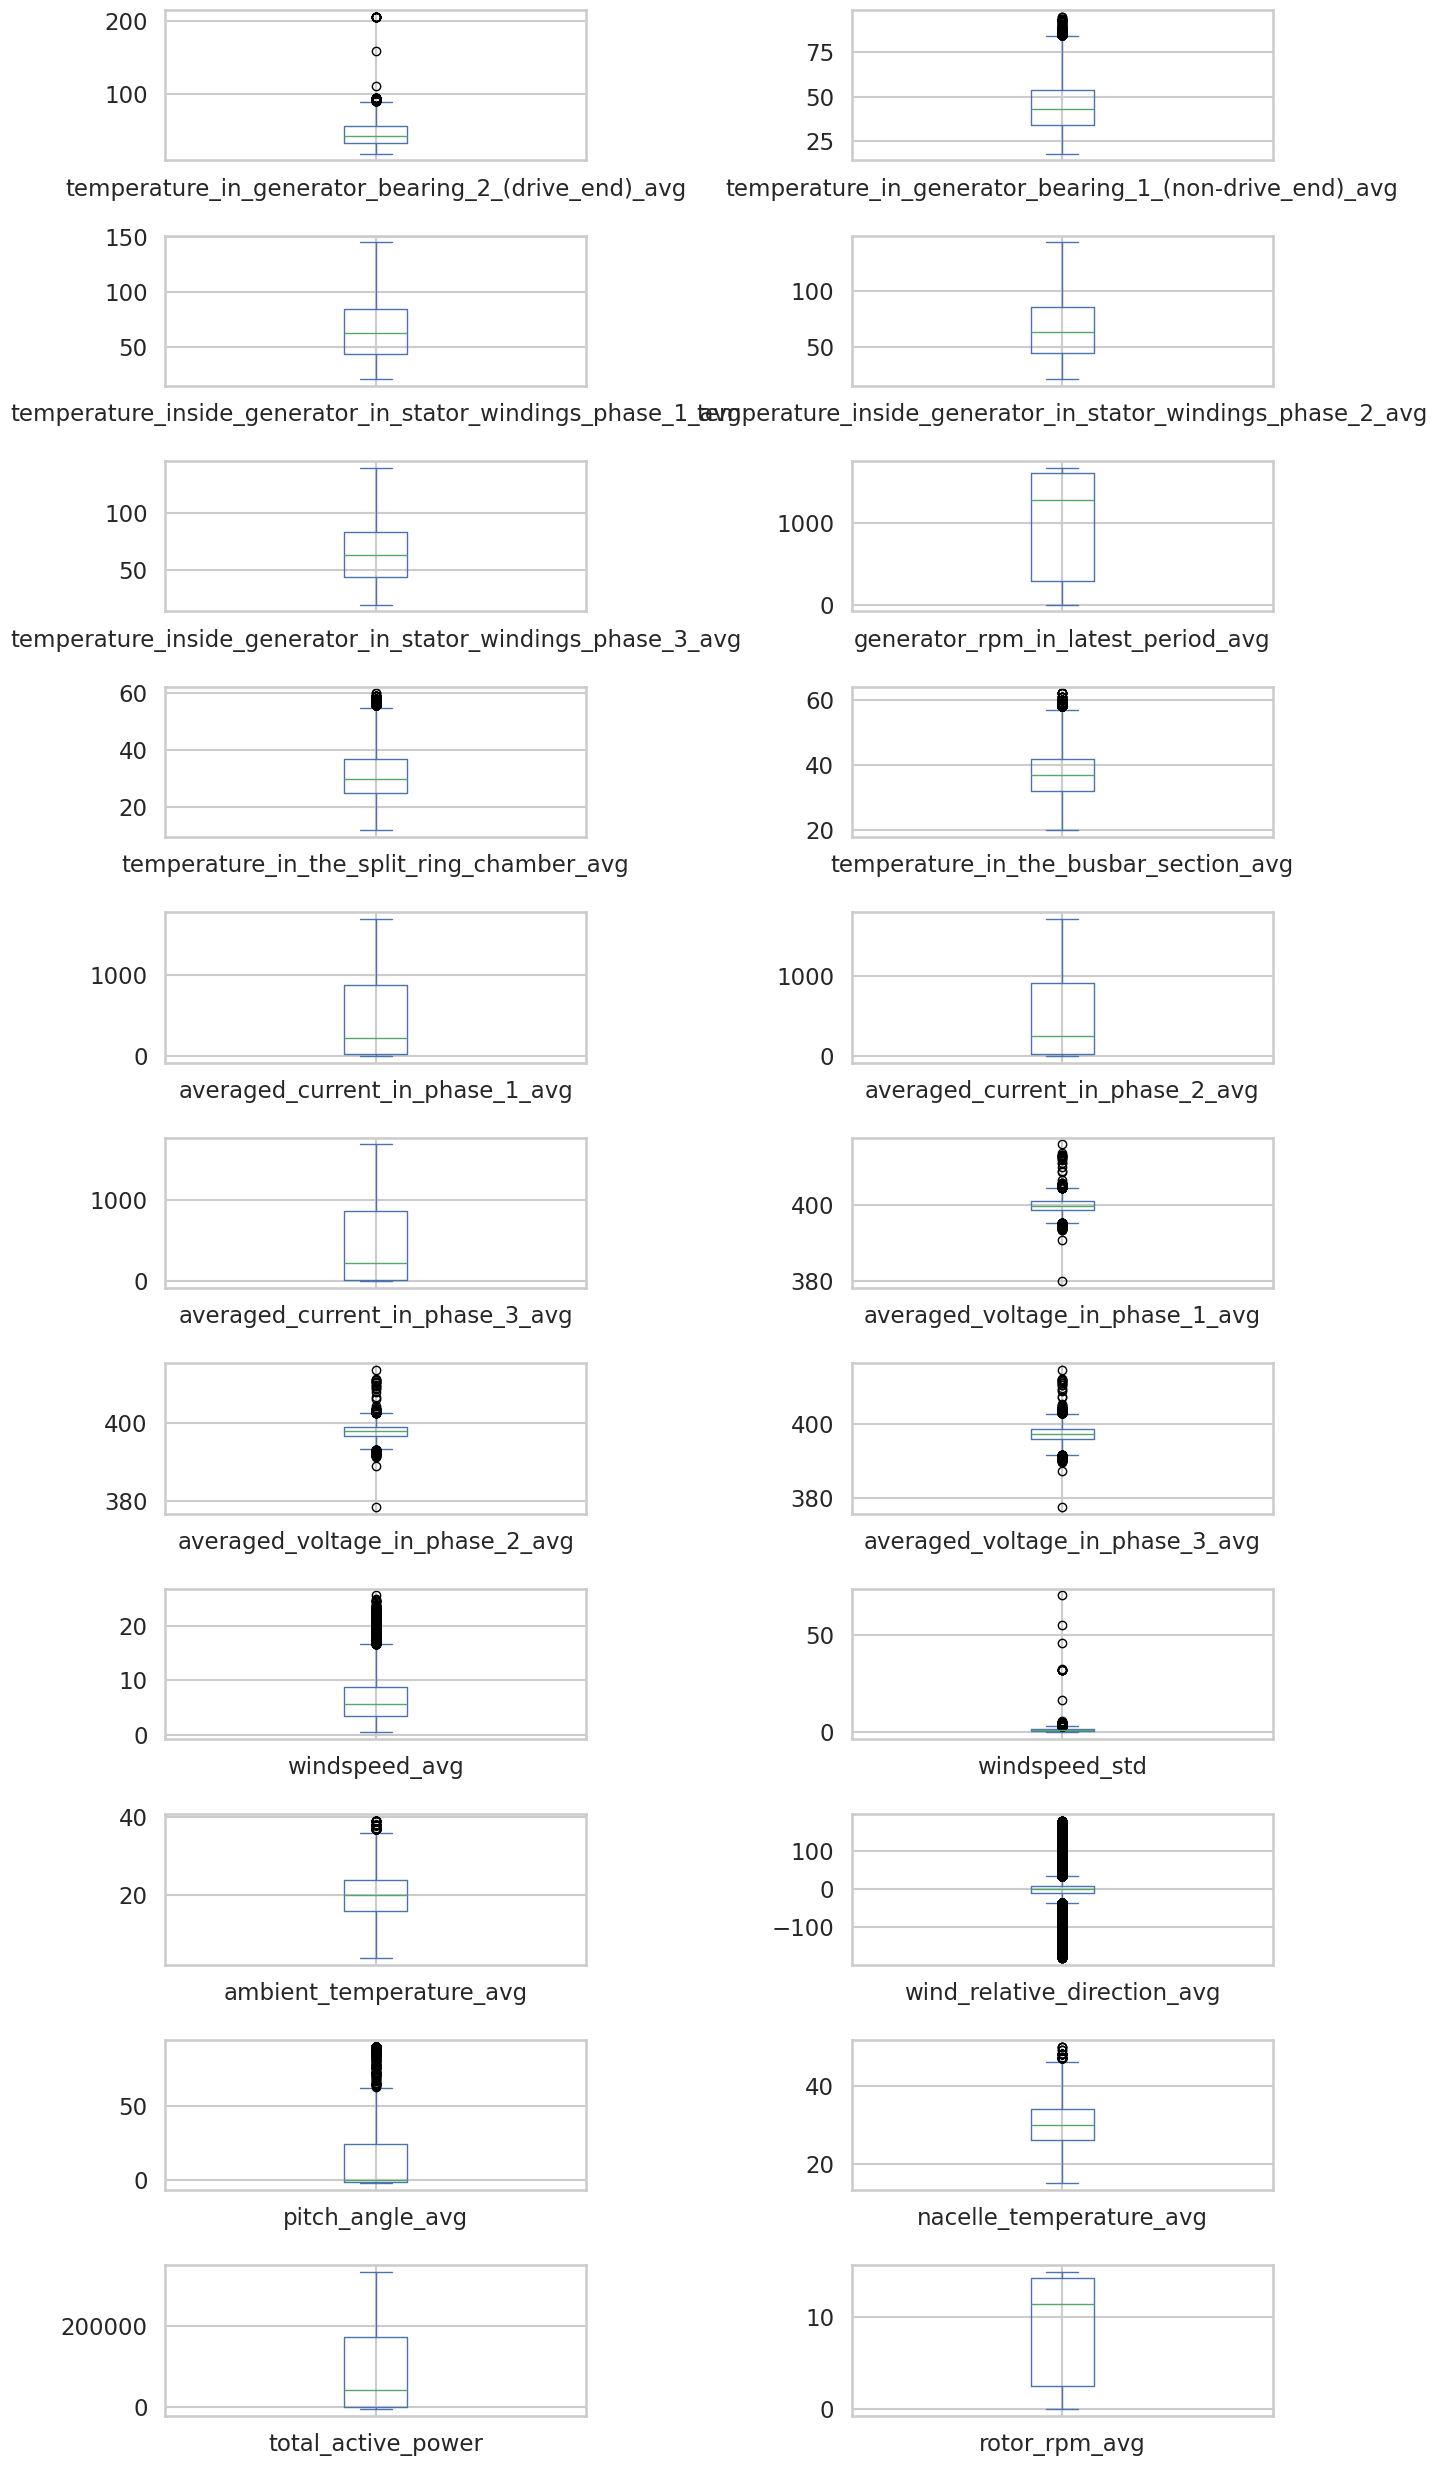

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
df_plot = df_scada.rename(columns=rename_col)
try:
    df_plot = df_plot.drop(columns=["status_type_id", "timestamp"])
except:
    print("shit")
df_plot.plot(kind="box", subplots=True, layout=(11,2), sharex=False, sharey=False, figsize=(14, 25)),
plt.tight_layout()
plt.show()
# df_plot

## Power curve cleaning
1. Use pitch angle as our reference: we can set a threshold of Xº to discard possible outliers
2. Use statistical approaches to clean some possible outliers

In [17]:
df_clean = df_scada[df_scada["status_type_id"] == 0].drop(columns="status_type_id")

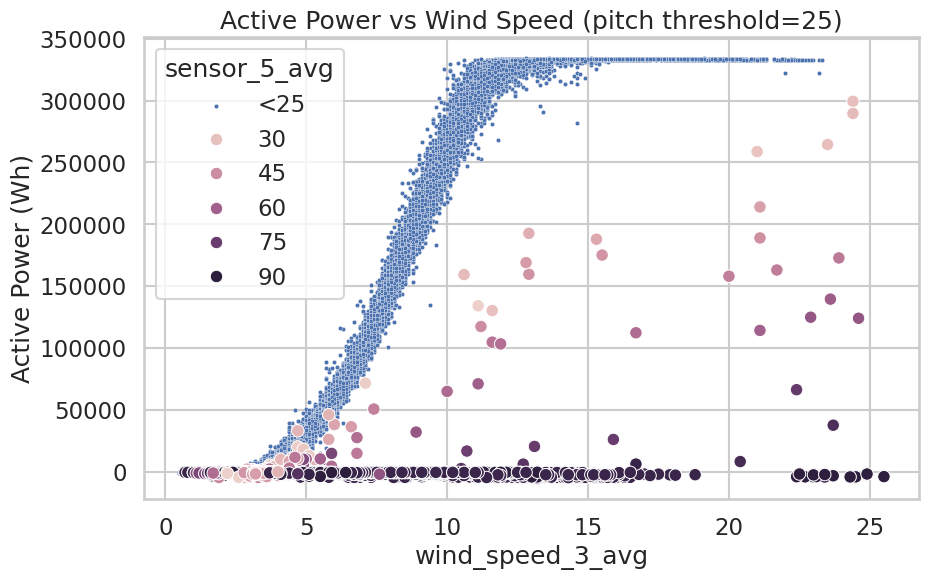

In [18]:
pitch_threshold = 25
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(df_clean[df_clean["sensor_5_avg"] < pitch_threshold], x="wind_speed_3_avg", y="sensor_50", s=10, label=f"<{pitch_threshold}")
sns.scatterplot(df_clean[df_clean["sensor_5_avg"] >= pitch_threshold], x="wind_speed_3_avg", y="sensor_50", hue="sensor_5_avg")
plt.ylabel("Active Power (Wh)")
plt.title(f"Active Power vs Wind Speed (pitch threshold={pitch_threshold})")
plt.show()

In [23]:
df_clean

,timestamp,sensor_13_avg,sensor_14_avg,sensor_15_avg,sensor_16_avg,sensor_17_avg,sensor_18_avg,sensor_19_avg,sensor_20_avg,sensor_23_avg,...,sensor_33_avg,sensor_34_avg,wind_speed_3_avg,wind_speed_3_std,sensor_0_avg,sensor_2_avg,sensor_5_avg,sensor_43_avg,sensor_50,sensor_52_avg
0,2022-10-12 10:20:00,71.0,68.0,126.0,125.0,120.0,1681.5,40.0,48.0,1667.5,...,399.2,400.7,13.2,3.0,17.0,-10.8,7.6,32.0,333190.0,14.9
1,2022-10-12 10:30:00,72.0,69.0,127.0,125.0,121.0,1680.9,40.0,48.0,1673.7,...,397.6,399.1,13.6,3.1,17.0,-6.2,9.0,33.0,333266.0,14.9
2,2022-10-12 10:40:00,72.0,69.0,127.0,126.0,121.0,1679.7,40.0,48.0,1674.9,...,397.0,398.3,12.7,3.1,17.0,-8.4,7.0,33.0,332999.0,14.9
3,2022-10-12 10:50:00,72.0,70.0,128.0,126.0,122.0,1681.0,40.0,48.0,1672.5,...,397.6,399.1,13.4,3.3,18.0,-3.7,8.5,35.0,333473.0,14.9
4,2022-10-12 11:00:00,72.0,70.0,128.0,127.0,122.0,1680.9,40.0,48.0,1668.9,...,396.8,398.1,12.7,2.8,17.0,10.5,6.2,35.0,332011.0,14.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51248,2023-10-05 09:30:00,55.0,64.0,120.0,118.0,114.0,1681.9,41.0,48.0,1669.3,...,396.7,397.9,13.9,2.7,22.0,0.9,8.4,36.0,333513.0,14.9
51249,2023-10-05 09:40:00,56.0,65.0,122.0,121.0,116.0,1680.6,42.0,48.0,1670.2,...,396.2,397.4,14.1,2.5,22.0,2.7,8.7,37.0,333256.0,14.9
51250,2023-10-05 09:50:00,57.0,66.0,123.0,122.0,117.0,1680.6,43.0,49.0,1662.2,...,396.7,398.0,12.9,2.7,23.0,-0.7,5.7,36.0,331971.0,14.9
51251,2023-10-05 10:00:00,57.0,67.0,125.0,123.0,118.0,1682.2,43.0,49.0,1656.1,...,399.1,400.3,12.6,2.4,23.0,-1.9,4.5,37.0,332114.0,14.9


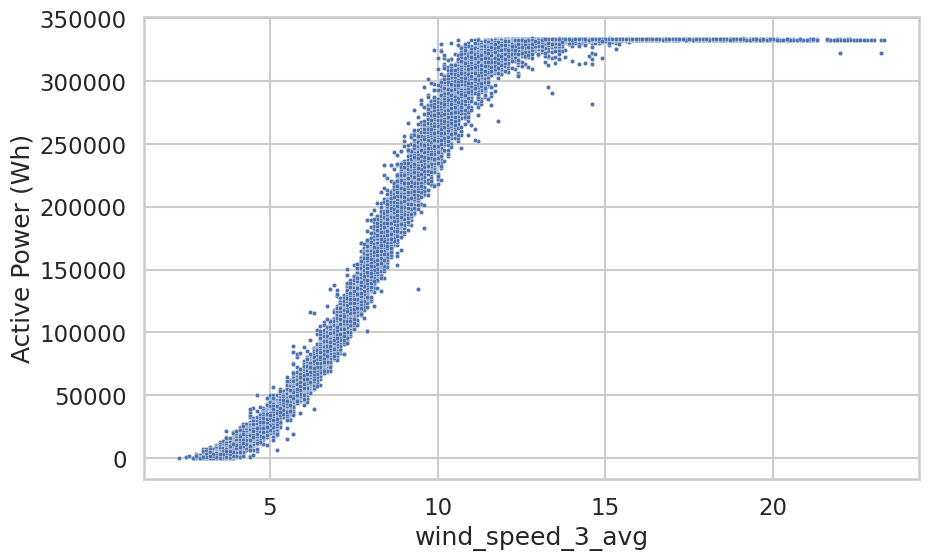

In [38]:
pitch_threshold = 25
df_clean = df_scada[
    (df_scada["status_type_id"] == 0) &
    (df_scada["sensor_5_avg"] < pitch_threshold) &
    (df_scada["sensor_50"] > 0) &
    (df_scada["train_test"] == "train")
].drop(columns=["status_type_id", "train_test"])

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(df_clean, x="wind_speed_3_avg", y="sensor_50", s=10)
plt.ylabel("Active Power (Wh)")
plt.show()

## Model

In [39]:
df_clean

,sensor_13_avg,sensor_14_avg,sensor_15_avg,sensor_16_avg,sensor_17_avg,sensor_18_avg,sensor_19_avg,sensor_20_avg,sensor_23_avg,sensor_24_avg,...,sensor_33_avg,sensor_34_avg,wind_speed_3_avg,wind_speed_3_std,sensor_0_avg,sensor_2_avg,sensor_5_avg,sensor_43_avg,sensor_50,sensor_52_avg
time_stamp,,,,,,,,,,,,,,,,,,,,,
2022-10-12 10:20:00,71.0,68.0,126.0,125.0,120.0,1681.5,40.0,48.0,1667.5,1682.4,...,399.2,400.7,13.2,3.0,17.0,-10.8,7.6,32.0,333190.0,14.9
2022-10-12 10:30:00,72.0,69.0,127.0,125.0,121.0,1680.9,40.0,48.0,1673.7,1689.6,...,397.6,399.1,13.6,3.1,17.0,-6.2,9.0,33.0,333266.0,14.9
2022-10-12 10:40:00,72.0,69.0,127.0,126.0,121.0,1679.7,40.0,48.0,1674.9,1692.3,...,397.0,398.3,12.7,3.1,17.0,-8.4,7.0,33.0,332999.0,14.9
2022-10-12 10:50:00,72.0,70.0,128.0,126.0,122.0,1681.0,40.0,48.0,1672.5,1688.1,...,397.6,399.1,13.4,3.3,18.0,-3.7,8.5,35.0,333473.0,14.9
2022-10-12 11:00:00,72.0,70.0,128.0,127.0,122.0,1680.9,40.0,48.0,1668.9,1686.4,...,396.8,398.1,12.7,2.8,17.0,10.5,6.2,35.0,332011.0,14.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-05 09:30:00,55.0,64.0,120.0,118.0,114.0,1681.9,41.0,48.0,1669.3,1692.5,...,396.7,397.9,13.9,2.7,22.0,0.9,8.4,36.0,333513.0,14.9
2023-10-05 09:40:00,56.0,65.0,122.0,121.0,116.0,1680.6,42.0,48.0,1670.2,1696.4,...,396.2,397.4,14.1,2.5,22.0,2.7,8.7,37.0,333256.0,14.9
2023-10-05 09:50:00,57.0,66.0,123.0,122.0,117.0,1680.6,43.0,49.0,1662.2,1688.7,...,396.7,398.0,12.9,2.7,23.0,-0.7,5.7,36.0,331971.0,14.9
